In [ ]:
!python --version

Python 3.13.15


In [1]:
# Install ultralytics if not already installed
%pip install -q ultralytics

import torch
from ultralytics import YOLO

# Verify GPU availability for training
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 12.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Using device: cuda


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Data processing and visualization modules imported successfully.")

Data processing and visualization modules imported successfully.


In [3]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define dataset path
dataset_path = '/content/drive/MyDrive/Ogmen-Robotics-Dataset'

# Check if dataset path exists and list its contents
if os.path.exists(dataset_path):
    print(f"Dataset located successfully at: {dataset_path}")
    print("Contents of the directory:")
    print(os.listdir(dataset_path))
else:
    print(f"Directory '{dataset_path}' not found. Please verify the path in Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset located successfully at: /content/drive/MyDrive/Ogmen-Robotics-Dataset
Contents of the directory:
['dataset']


In [4]:
import os

# Path to the actual inner dataset folder
inner_dataset_path = '/content/drive/MyDrive/Ogmen-Robotics-Dataset/dataset'

if os.path.exists(inner_dataset_path):
    print("Contents of 'dataset' folder:")
    items = os.listdir(inner_dataset_path)
    print(items)

    # Check for yaml configuration files
    yaml_files = [f for f in items if f.endswith('.yaml') or f.endswith('.yml')]
    if yaml_files:
        print(f"\nFound YAML configuration file(s): {yaml_files}")
    else:
        print("\nNo YAML configuration files found directly in this directory.")
else:
    print(f"The directory {inner_dataset_path} does not exist.")

Contents of 'dataset' folder:
['standing', 'sitting', 'lying']

No YAML configuration files found directly in this directory.


In [5]:
import os

base_dir = '/content/drive/MyDrive/Ogmen-Robotics-Dataset/dataset'
classes = ['standing', 'sitting', 'lying']

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        print(f"Class '{cls}' has {len(images)} images.")
    else:
        print(f"Class folder '{cls}' not found at {class_path}")

Class 'standing' has 0 images.
Class 'sitting' has 0 images.
Class 'lying' has 0 images.


In [6]:
import os

base_dir = '/content/drive/MyDrive/Ogmen-Robotics-Dataset/dataset'

print("Searching for images and folders recursively inside:", base_dir)
for root, dirs, files in os.walk(base_dir):
    # Filter to only list image files
    images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
    if len(images) > 0 or len(dirs) > 0:
        depth = root.replace(base_dir, '').count(os.sep)
        indent = '  ' * depth
        print(f"{indent}📁 {os.path.basename(root)}/ (subdirs: {len(dirs)}, images: {len(images)})")

Searching for images and folders recursively inside: /content/drive/MyDrive/Ogmen-Robotics-Dataset/dataset
📁 dataset/ (subdirs: 3, images: 0)
  📁 standing/ (subdirs: 2, images: 0)
    📁 test/ (subdirs: 2, images: 0)
      📁 images/ (subdirs: 0, images: 10)
    📁 train/ (subdirs: 2, images: 0)
      📁 images/ (subdirs: 0, images: 50)
  📁 sitting/ (subdirs: 2, images: 0)
    📁 test/ (subdirs: 2, images: 0)
      📁 images/ (subdirs: 0, images: 10)
    📁 train/ (subdirs: 2, images: 0)
      📁 images/ (subdirs: 0, images: 50)
  📁 lying/ (subdirs: 2, images: 0)
    📁 test/ (subdirs: 2, images: 0)
      📁 images/ (subdirs: 0, images: 10)
    📁 train/ (subdirs: 2, images: 0)
      📁 images/ (subdirs: 0, images: 50)


In [7]:
import os
import shutil
from pathlib import Path

# Source and Destination paths
source_dataset = '/content/drive/MyDrive/Ogmen-Robotics-Dataset/dataset'
target_dataset = '/content/yolo_dataset'

classes = ['standing', 'sitting', 'lying']
splits = ['train', 'test']  # Using 'test' as validation split

# Create target YOLO structure
for split in splits:
    os.makedirs(os.path.join(target_dataset, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(target_dataset, split, 'labels'), exist_ok=True)

print("Re-organizing dataset to a unified YOLOv8 format...")

# Map class names to IDs
class_map = {cls: idx for idx, cls in enumerate(classes)}

for cls in classes:
    for split in splits:
        # Source directories
        src_img_dir = os.path.join(source_dataset, cls, split, 'images')
        src_lbl_dir = os.path.join(source_dataset, cls, split, 'labels')

        # Target directories
        dst_img_dir = os.path.join(target_dataset, split, 'images')
        dst_lbl_dir = os.path.join(target_dataset, split, 'labels')

        # Copy images
        if os.path.exists(src_img_dir):
            for img_file in os.listdir(src_img_dir):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    shutil.copy2(os.path.join(src_img_dir, img_file), os.path.join(dst_img_dir, img_file))

        # Copy labels if they exist
        if os.path.exists(src_lbl_dir):
            for lbl_file in os.listdir(src_lbl_dir):
                if lbl_file.endswith('.txt'):
                    shutil.copy2(os.path.join(src_lbl_dir, lbl_file), os.path.join(dst_lbl_dir, lbl_file))

print("Dataset structure unified at:", target_dataset)
print(f"Train images: {len(os.listdir(os.path.join(target_dataset, 'train', 'images')))}")
print(f"Test/Val images: {len(os.listdir(os.path.join(target_dataset, 'test', 'images')))}")

# Generate data.yaml
yaml_content = f"""
path: {target_dataset}
train: train/images
val: test/images

names:
  0: standing
  1: sitting
  2: lying
"""

yaml_path = os.path.join(target_dataset, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"\nCreated YAML configuration file at: {yaml_path}")

Re-organizing dataset to a unified YOLOv8 format...
Dataset structure unified at: /content/yolo_dataset
Train images: 150
Test/Val images: 30

Created YAML configuration file at: /content/yolo_dataset/data.yaml


In [22]:
import cv2
import os
from ultralytics import YOLO

def normalize_all_labels(dataset_dir):
    splits = ['train', 'test']
    for split in splits:
        img_dir = os.path.join(dataset_dir, split, 'images')
        lbl_dir = os.path.join(dataset_dir, split, 'labels')

        if not os.path.exists(lbl_dir):
            continue

        for lbl_name in os.listdir(lbl_dir):
            if not lbl_name.endswith('.txt'):
                continue

            lbl_path = os.path.join(lbl_dir, lbl_name)
            img_name_base = os.path.splitext(lbl_name)[0]
            img_path = None
            for ext in ['.jpg', '.jpeg', '.png', '.webp']:
                test_path = os.path.join(img_dir, img_name_base + ext)
                if os.path.exists(test_path):
                    img_path = test_path
                    break

            if not img_path:
                continue

            img = cv2.imread(img_path)
            if img is None:
                continue
            h, w, _ = img.shape

            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            normalized_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = parts[0]

                # Read bounding box coordinates
                coords = [float(x) for x in parts[1:5]]

                # If any coordinate is strictly greater than 1.0, normalize it using the image dimensions
                if any(c > 1.0 for c in coords):
                    x_center = coords[0] / w
                    y_center = coords[1] / h
                    box_w = coords[2] / w
                    box_h = coords[3] / h
                else:
                    x_center, y_center, box_w, box_h = coords

                # Enforce boundaries to stay strictly within [0.0, 1.0]
                x_center = max(0.0, min(1.0, x_center))
                y_center = max(0.0, min(1.0, y_center))
                box_w = max(0.0, min(1.0, box_w))
                box_h = max(0.0, min(1.0, box_h))

                # Reconstruct line without keypoints or invalid excess attributes
                normalized_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}")

            with open(lbl_path, 'w') as f:
                f.write('\n'.join(normalized_lines))

print("Ensuring ALL training and testing label coordinates are normalized...")
normalize_all_labels('/content/yolo_dataset')
print("Normalization complete. Starting retraining...")

# Re-initialize a fresh YOLOv8 Nano model
retrained_model = YOLO('yolov8n.pt')

# Run the training process on the fully corrected dataset
retrained_results = retrained_model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    device=device,
    name='yolov8n_ogmen_robotics_corrected'
)

Ensuring ALL training and testing label coordinates are normalized...
Normalization complete. Starting retraining...
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yo

Evaluating 30 test images using the retrained model:

Image Name                | Ground Truth    | Prediction      | Confidence
------------------------------------------------------------------------
lying_test_0001.jpg       | lying           | lying           | 68.17%    
lying_test_0002.jpg       | lying           | no_detection    | N/A       
lying_test_0003.jpg       | lying           | lying           | 56.20%    
lying_test_0004.jpg       | lying           | sitting         | 43.74%    
lying_test_0005.jpg       | lying           | lying           | 89.53%    
lying_test_0006.jpg       | lying           | lying           | 34.94%    
lying_test_0007.jpg       | lying           | lying           | 41.29%    
lying_test_0008.jpg       | lying           | lying           | 80.42%    
lying_test_0009.jpg       | lying           | lying           | 64.79%    
lying_test_0010.jpg       | lying           | lying           | 58.33%    
sitting_test_0001.jpg     | sitting         | si

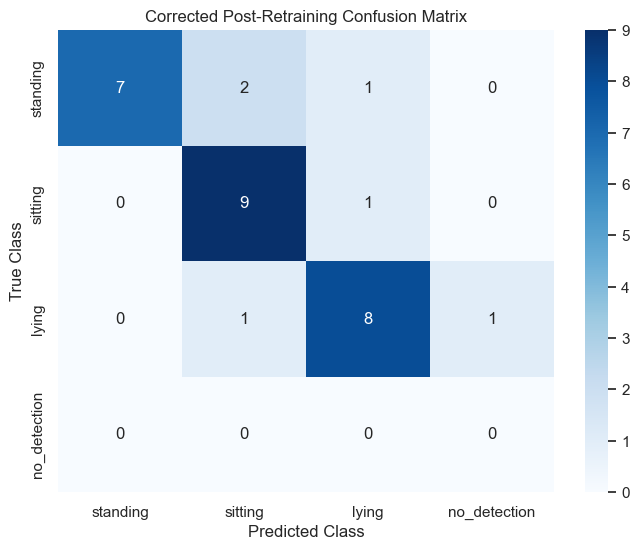

In [23]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the newly retrained model
best_retrained_model_path = '/content/runs/detect/yolov8n_ogmen_robotics_corrected-2/weights/best.pt'
model = YOLO(best_retrained_model_path)

# 2. Setup paths and parameters
test_images_dir = '/content/yolo_dataset/test/images'
test_labels_dir = '/content/yolo_dataset/test/labels'

test_images = sorted([f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
class_names = ['standing', 'sitting', 'lying']

y_true = []
y_pred = []

print(f"Evaluating {len(test_images)} test images using the retrained model:\n")
print(f"{'Image Name':<25} | {'Ground Truth':<15} | {'Prediction':<15} | {'Confidence':<10}")
print("-" * 72)

# 3. Predict and gather classifications
for img_name in test_images:
    img_path = os.path.join(test_images_dir, img_name)
    lbl_name = os.path.splitext(img_name)[0] + '.txt'
    lbl_path = os.path.join(test_labels_dir, lbl_name)

    # Get true class index
    gt_class_idx = None
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                gt_class_idx = int(first_line.split()[0])

    if gt_class_idx is None:
        # Fallback to filename prefix if file is missing
        for idx, cls in enumerate(class_names):
            if img_name.startswith(cls):
                gt_class_idx = idx
                break

    y_true.append(gt_class_idx)

    # Run inference
    results = model(img_path, verbose=False)
    pred_class_idx = -1
    highest_conf = -1.0

    for r in results:
        boxes = r.boxes
        for box in boxes:
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            if conf > highest_conf:
                highest_conf = conf
                pred_class_idx = cls

    pred_idx = pred_class_idx if pred_class_idx != -1 else 3
    y_pred.append(pred_idx)

    # Print line-by-line prediction details
    gt_label = class_names[gt_class_idx]
    pred_label = class_names[pred_idx] if pred_idx < 3 else 'no_detection'
    conf_str = f"{highest_conf:.2%}" if highest_conf != -1.0 else "N/A"
    print(f"{img_name:<25} | {gt_label:<15} | {pred_label:<15} | {conf_str:<10}")

# 4. Compute overall metrics
target_names = class_names.copy()
if 3 in y_pred:
    target_names.append('no_detection')

y_true_labels = [class_names[i] for i in y_true]
y_pred_labels = [target_names[i] for i in y_pred]

print("\n=== Overall Classification Accuracy ===")
acc = accuracy_score(y_true_labels, y_pred_labels)
print(f"{acc * 100:.2f}%")

print("\n=== Per-Class Precision & Recall ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, zero_division=0))

# 5. Generate and plot corrected confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=target_names)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Corrected Post-Retraining Confusion Matrix')
plt.show()


image 1/1 /content/yolo_dataset/test/images/sitting_test_0008.jpg: 640x480 1 sitting, 11.0ms
Speed: 2.2ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


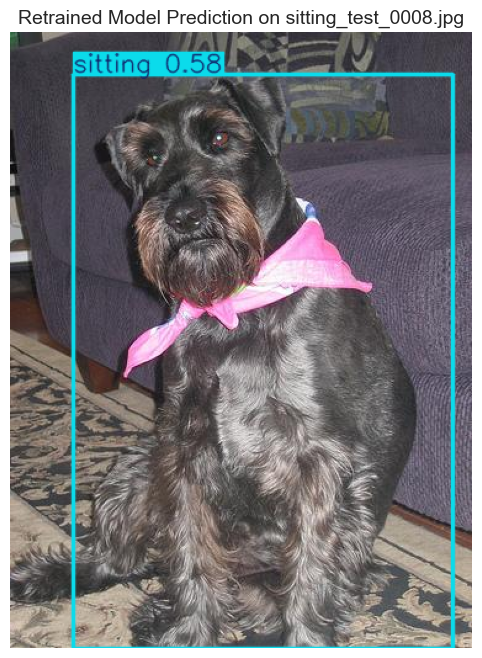

In [24]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load the newly retrained best model
best_retrained_model_path = '/content/runs/detect/yolov8n_ogmen_robotics_corrected-2/weights/best.pt'
model = YOLO(best_retrained_model_path)

# 2. Get a sample image from the test set
test_images_dir = '/content/yolo_dataset/test/images'
test_images = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    # We'll use the first available test image
    sample_img_path = test_images[0]

    # 3. Run inference
    results = model(sample_img_path)

    # 4. Plot and display predictions
    for r in results:
        im_array = r.plot()  # plot predictions as a BGR numpy array
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Retrained Model Prediction on {os.path.basename(sample_img_path)}", fontsize=14)
        plt.show()
else:
    print("No test images found to run inference on.")

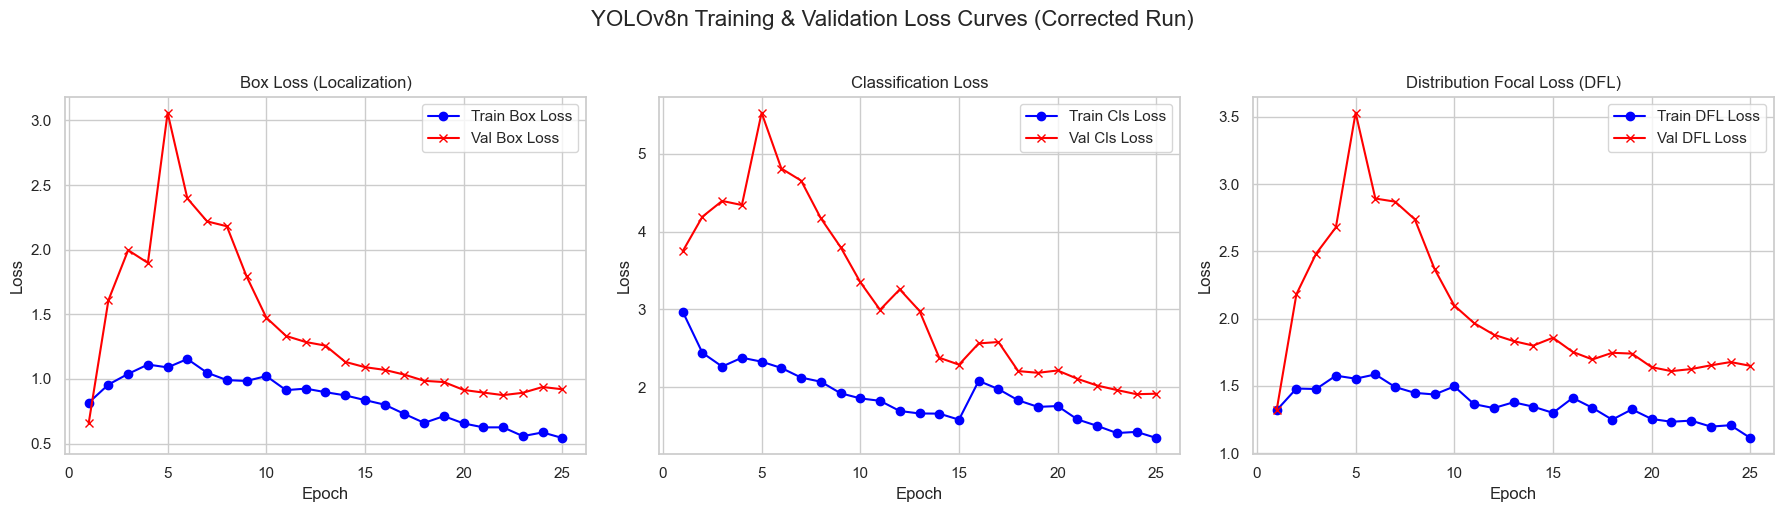

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the results.csv of the corrected retraining run
results_path = '/content/runs/detect/yolov8n_ogmen_robotics_corrected-2/results.csv'

if os.path.exists(results_path):
    # Load training logs
    df = pd.read_csv(results_path)
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Create plots for losses
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Box Loss
    axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue', marker='o')
    axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='red', marker='x')
    axes[0].set_title('Box Loss (Localization)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Classification Loss
    axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color='blue', marker='o')
    axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', color='red', marker='x')
    axes[1].set_title('Classification Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    # 3. DFL Loss
    axes[2].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', color='blue', marker='o')
    axes[2].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', color='red', marker='x')
    axes[2].set_title('Distribution Focal Loss (DFL)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True)

    plt.suptitle('YOLOv8n Training & Validation Loss Curves (Corrected Run)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find training logs at: {results_path}")